# Translation-Based ROI Crop Augmentation
**Environment:** Google Colab + Google Drive  
**Purpose:** Generate multiple diverse training crops per image by randomly shifting the crop window  
**Why this helps:** The baseline crop always centres exactly on the lesion bbox. Translated crops teach the model to recognise lesions at different positions within the crop — reducing position bias and effectively multiplying dataset size 5–10×.

### Workflow
1. Mount Google Drive
2. Install / verify dependencies
3. Set your Drive paths in CONFIG
4. Run augmentation

### How translation works
```
Original image
┌──────────────────────────────────────┐
│    ┌─────────────────────────┐       │
│    │  baseline crop (centre) │       │
│    │    ┌──────────┐         │       │
│    │    │  LESION  │         │       │
│    │    └──────────┘         │       │
│    └─────────────────────────┘       │
│  ┌──────────────────────────┐        │  ← shifted right+down
│  │    ┌──────────┐          │        │
│  │    │  LESION  │          │        │
│  │    └──────────┘          │        │
│  └──────────────────────────┘        │
└──────────────────────────────────────┘
```
Lesion always stays **inside** the crop. Crop always stays **inside** the image.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 0 — Mount Google Drive
# Run this cell first. A link will appear — click it, sign in,
# copy the authorisation code and paste it in the box below.
# ══════════════════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
print('Drive mounted.')
print('Your Drive root:', os.listdir('/content/drive/MyDrive')[:8], '...')


Mounted at /content/drive
Drive mounted.
Your Drive root: ['Classroom', 'L1S1', 'Sem Regitration', 'Photo', 'CamScanner 09-22-2023 16.25.jpg', 'Combinational Circuits  and Sequential circuits..gsheet', 'Coprocessor vs Peripherals table.gsheet', 'Untitled document (4).gdoc'] ...


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 0b — Verify dependencies (all pre-installed in Colab)
# ══════════════════════════════════════════════════════════════════════════

import cv2, numpy as np, matplotlib
from pathlib import Path
from tqdm.notebook import tqdm   # notebook-style progress bar
import random, os, json
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print(f'OpenCV   : {cv2.__version__}')
print(f'NumPy    : {np.__version__}')
print(f'Matplotlib: {matplotlib.__version__}')
print('All dependencies ready.')


OpenCV   : 4.13.0
NumPy    : 2.0.2
Matplotlib: 3.10.0
All dependencies ready.


In [ ]:
# Imports — already handled in the dependency cell above.
# This cell kept as placeholder for any additional imports you need.
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from tqdm.notebook import tqdm
import random, os, json
from collections import defaultdict
print('Imports OK.')


Imports OK.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# CONFIG — Edit ONLY this cell to match your Google Drive folder layout
# ══════════════════════════════════════════════════════════════════════════

# ── Google Drive base path ────────────────────────────────────────────────
# Everything lives under this folder in your Drive.
# Example: if your Drive has  MyDrive/FYP/data/output/crop_oct
#          set DRIVE_BASE = '/content/drive/MyDrive/FYP'
DRIVE_BASE = '/content/drive/MyDrive/FYP'   # ← CHANGE THIS

# ── Input folders (outputs of prepare_roi_dataset.ipynb) ─────────────────
CROP_OCT_DIR  = f'{DRIVE_BASE}/data/images'
CROP_MASK_DIR = f'{DRIVE_BASE}/data/masks'

# ── Output folders (augmented crops will be saved here) ───────────────────
# Saved directly to Drive so they persist after Colab session ends.
OUT_OCT_DIR   = f'{DRIVE_BASE}/data/augmented/crop_oct'
OUT_MASK_DIR  = f'{DRIVE_BASE}/data/augmented/crop_mask'

# ── Translation augmentation parameters ──────────────────────────────────
N_TRANSLATIONS    = 5     # translated crops per image (total = N+1 with original)
MARGIN            = 20    # pixels of context added around lesion bbox
MAX_SHIFT_X       = 40    # max horizontal shift  [-MAX_SHIFT_X, +MAX_SHIFT_X]
MAX_SHIFT_Y       = 20    # max vertical shift    [-MAX_SHIFT_Y, +MAX_SHIFT_Y]
MIN_LESION_MARGIN = 5     # min pixels between lesion edge and crop edge after shift
SAVE_ORIGINAL     = True  # also save the unshifted baseline crop
BG_THRESHOLD      = 15    # mask pixels below this are background
SEED              = 42
EXTENSIONS        = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff'}

# ── Class colour map (must match your masks exactly) ─────────────────────
CLASS_INFO = {
    0: {'name': 'Background',    'color': (0,   0,   0)},
    1: {'name': 'Retinal Layer', 'color': (255, 0,   255)},
    2: {'name': 'PED',           'color': (255, 255, 0)},
    3: {'name': 'SRF',           'color': (255, 0,   0)},
    4: {'name': 'IRF',           'color': (0,   0,   255)},
    5: {'name': 'RPE',           'color': (0,   255, 0)},
}

# ── Validate paths before continuing ─────────────────────────────────────
for label, path in [('crop_oct',  CROP_OCT_DIR),
                     ('crop_mask', CROP_MASK_DIR)]:
    if not Path(path).exists():
        raise FileNotFoundError(
            f'Input folder not found: {path}\n'
            f'Check DRIVE_BASE and folder names.'
        )

os.makedirs(OUT_OCT_DIR,  exist_ok=True)
os.makedirs(OUT_MASK_DIR, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)

print('Config loaded and paths verified.')
print(f'  Input  OCT    : {CROP_OCT_DIR}')
print(f'  Input  mask   : {CROP_MASK_DIR}')
print(f'  Output OCT    : {OUT_OCT_DIR}')
print(f'  Output mask   : {OUT_MASK_DIR}')
print(f'  Translations  : {N_TRANSLATIONS} per image')
print(f'  Max shift X/Y : {MAX_SHIFT_X}px / {MAX_SHIFT_Y}px')
n_input = len([f for f in Path(CROP_OCT_DIR).iterdir()
               if f.suffix.lower() in EXTENSIONS])
print(f'  Input images  : {n_input}')
n_out_est = n_input * (N_TRANSLATIONS + (1 if SAVE_ORIGINAL else 0))
print(f'  Expected output: ~{n_out_est} crops  ({n_out_est/max(n_input,1):.0f}× multiplier)')


Config loaded and paths verified.
  Input  OCT    : /content/drive/MyDrive/FYP/data/images
  Input  mask   : /content/drive/MyDrive/FYP/data/masks
  Output OCT    : /content/drive/MyDrive/FYP/data/augmented/crop_oct
  Output mask   : /content/drive/MyDrive/FYP/data/augmented/crop_mask
  Translations  : 5 per image
  Max shift X/Y : 40px / 20px
  Input images  : 3049
  Expected output: ~18294 crops  (6× multiplier)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# CORE FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════

def get_lesion_bbox(mask_bgr, bg_threshold=BG_THRESHOLD):
    """
    Find tight bounding box of all non-background pixels in mask.
    Returns (r_min, r_max, c_min, c_max) or None if mask is empty.
    """
    mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    fg = (mask_rgb > bg_threshold).any(axis=2)     # H×W bool
    rows = np.where(np.any(fg, axis=1))[0]
    cols = np.where(np.any(fg, axis=0))[0]
    if len(rows) == 0:
        return None
    return int(rows[0]), int(rows[-1]), int(cols[0]), int(cols[-1])


def get_baseline_crop_window(lesion_bbox, img_h, img_w, margin=MARGIN):
    """
    Expand lesion bbox by margin on all sides, clipped to image.
    Returns (r0, r1, c0, c1) — the baseline (unshifted) crop window.
    """
    r_min, r_max, c_min, c_max = lesion_bbox
    r0 = max(0, r_min - margin)
    r1 = min(img_h - 1, r_max + margin)
    c0 = max(0, c_min - margin)
    c1 = min(img_w - 1, c_max + margin)
    return r0, r1, c0, c1


def translate_crop_window(base_window, shift_r, shift_c,
                          lesion_bbox, img_h, img_w,
                          min_lesion_margin=MIN_LESION_MARGIN):
    """
    Shift the crop window by (shift_r, shift_c) pixels.

    Constraints enforced:
      1. Crop stays within image boundaries
      2. Lesion bbox stays inside crop with at least min_lesion_margin px

    Returns:
      (r0, r1, c0, c1)  — the translated crop window
      actual_shift      — (actual_dr, actual_dc) after clamping
      valid             — False if constraints cannot be satisfied
    """
    r0_base, r1_base, c0_base, c1_base = base_window
    crop_h = r1_base - r0_base
    crop_w = c1_base - c0_base
    l_r0, l_r1, l_c0, l_c1 = lesion_bbox

    # Proposed shifted position
    r0_new = r0_base + shift_r
    c0_new = c0_base + shift_c
    r1_new = r0_new + crop_h
    c1_new = c0_new + crop_w

    # ── Constraint 1: crop must stay within image ─────────────────────
    r0_new = max(0, r0_new)
    c0_new = max(0, c0_new)
    r1_new = min(img_h - 1, r1_new)
    c1_new = min(img_w - 1, c1_new)

    # Recompute r0/c0 if r1/c1 were clamped (preserve crop size)
    r0_new = max(0, r1_new - crop_h)
    c0_new = max(0, c1_new - crop_w)

    # ── Constraint 2: lesion must stay inside crop with margin ────────
    # Lesion position relative to new crop origin
    lesion_inside_r0 = l_r0 - r0_new
    lesion_inside_r1 = l_r1 - r0_new
    lesion_inside_c0 = l_c0 - c0_new
    lesion_inside_c1 = l_c1 - c0_new

    crop_h_actual = r1_new - r0_new
    crop_w_actual = c1_new - c0_new

    # Check all four sides have enough margin
    if (lesion_inside_r0 < min_lesion_margin or
        lesion_inside_c0 < min_lesion_margin or
        lesion_inside_r1 > crop_h_actual - min_lesion_margin or
        lesion_inside_c1 > crop_w_actual - min_lesion_margin):
        return None, None, False

    actual_dr = r0_new - r0_base
    actual_dc = c0_new - c0_base
    return (r0_new, r1_new, c0_new, c1_new), (actual_dr, actual_dc), True


def sample_valid_translations(base_window, lesion_bbox, img_h, img_w,
                              n_translations, max_shift_x, max_shift_y,
                              min_lesion_margin=MIN_LESION_MARGIN,
                              max_attempts=500):
    """
    Randomly sample N valid translated crop windows.
    Tries up to max_attempts times to find n_translations valid shifts.

    Returns list of (window, shift) tuples.
    """
    valid_windows = []
    seen_shifts   = set()

    for _ in range(max_attempts):
        if len(valid_windows) >= n_translations:
            break

        shift_r = random.randint(-max_shift_y, max_shift_y)
        shift_c = random.randint(-max_shift_x, max_shift_x)

        # Skip zero shift (that's the original crop)
        if shift_r == 0 and shift_c == 0:
            continue

        win, actual_shift, ok = translate_crop_window(
            base_window, shift_r, shift_c,
            lesion_bbox, img_h, img_w, min_lesion_margin
        )

        if not ok:
            continue

        # Deduplicate: skip if this exact window already collected
        key = win
        if key in seen_shifts:
            continue

        seen_shifts.add(key)
        valid_windows.append((win, actual_shift))

    return valid_windows


def crop_image_and_mask(oct_bgr, mask_bgr, window):
    """
    Crop both OCT and mask identically using the given window.
    window: (r0, r1, c0, c1)
    Returns (oct_crop, mask_crop) — same spatial size, no resize.
    """
    r0, r1, c0, c1 = window
    return oct_bgr[r0:r1+1, c0:c1+1], mask_bgr[r0:r1+1, c0:c1+1]


print('Core functions ready.')

Core functions ready.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 1 — Verify one sample before processing everything
# ══════════════════════════════════════════════════════════════════════════

oct_dir  = Path(CROP_OCT_DIR)
mask_dir = Path(CROP_MASK_DIR)

all_files = sorted([f for f in oct_dir.iterdir()
                    if f.suffix.lower() in EXTENSIONS])
print(f'Found {len(all_files)} OCT crops in input folder.')
if len(all_files) == 0:
    raise FileNotFoundError(f'No images found in {CROP_OCT_DIR}')

# ── Load sample ────────────────────────────────────────────────────────
sample_path = all_files[0]
oct_bgr     = cv2.imread(str(sample_path))
mask_bgr    = cv2.imread(str(mask_dir / sample_path.name), cv2.IMREAD_COLOR)
img_h, img_w = oct_bgr.shape[:2]

# ── Get lesion bbox + baseline window ─────────────────────────────────
lesion_bbox  = get_lesion_bbox(mask_bgr)
base_window  = get_baseline_crop_window(lesion_bbox, img_h, img_w)
translations = sample_valid_translations(
    base_window, lesion_bbox, img_h, img_w,
    N_TRANSLATIONS, MAX_SHIFT_X, MAX_SHIFT_Y
)

print(f'\nSample: {sample_path.name}')
print(f'  Image size       : {img_w}w × {img_h}h')
print(f'  Lesion bbox      : rows {lesion_bbox[0]}–{lesion_bbox[1]},  cols {lesion_bbox[2]}–{lesion_bbox[3]}')
print(f'  Baseline window  : rows {base_window[0]}–{base_window[1]},  cols {base_window[2]}–{base_window[3]}')
print(f'  Baseline crop    : {base_window[1]-base_window[0]+1}h × {base_window[3]-base_window[2]+1}w')
print(f'  Valid translations found: {len(translations)} / {N_TRANSLATIONS} requested')
for i, (win, shift) in enumerate(translations):
    print(f'    [{i+1}] shift=({shift[0]:+d}r, {shift[1]:+d}c)  →  '
          f'rows {win[0]}–{win[1]}, cols {win[2]}–{win[3]}')

Found 3049 OCT crops in input folder.

Sample: 0.png
  Image size       : 570w × 380h
  Lesion bbox      : rows 13–169,  cols 39–549
  Baseline window  : rows 0–189,  cols 19–569
  Baseline crop    : 190h × 551w
  Valid translations found: 5 / 5 requested
    [1] shift=(+0r, -12c)  →  rows 0–184, cols 7–557
    [2] shift=(+0r, -13c)  →  rows 0–174, cols 6–556
    [3] shift=(+0r, +0c)  →  rows 0–183, cols 19–569
    [4] shift=(+7r, +0c)  →  rows 7–196, cols 19–569
    [5] shift=(+0r, +0c)  →  rows 0–182, cols 19–569


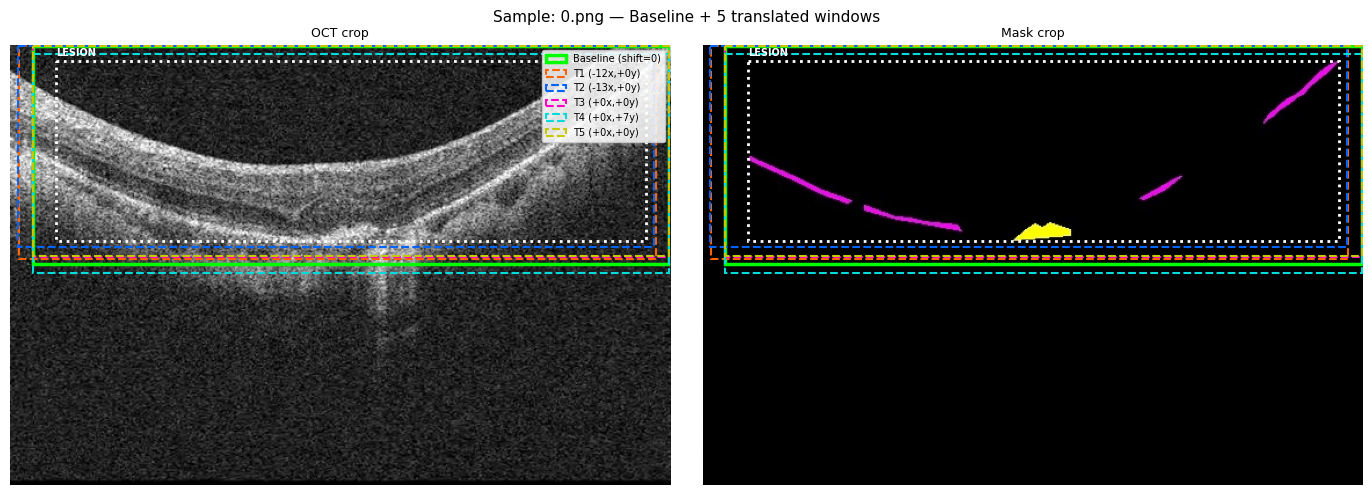

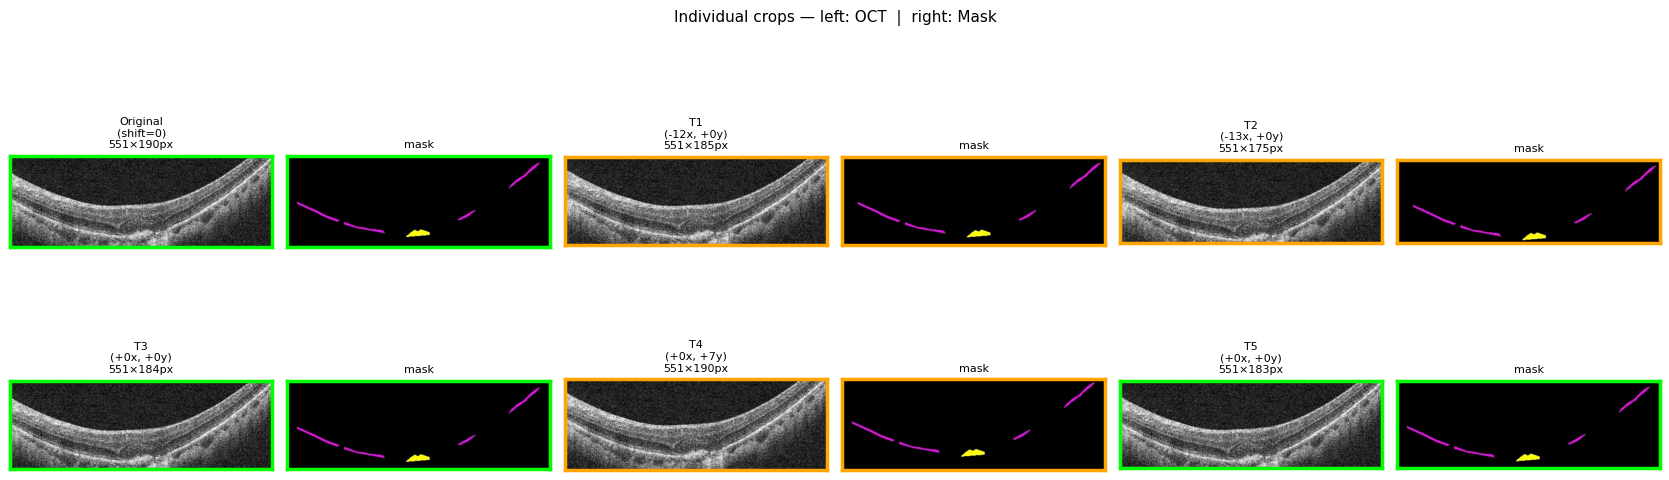

Visualisation complete. If crops look correct, run the next cell to process all images.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 2 — Visualise the sample (OCT + mask + all crop windows)
# ══════════════════════════════════════════════════════════════════════════

N_SHOW = len(translations)   # number of translated crops to show
N_COLS = 3                   # columns per row in the grid

# Build colour palette for crop windows
window_colors = [
    (0,   255, 0),    # green   — baseline
    (255, 100, 0),    # orange
    (0,   100, 255),  # blue
    (255, 0,   200),  # magenta
    (0,   220, 220),  # cyan
    (200, 200, 0),    # yellow
]

oct_rgb  = cv2.cvtColor(oct_bgr,  cv2.COLOR_BGR2RGB)
mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)

# ── Panel A: full OCT with all crop windows drawn ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Sample: {sample_path.name} — Baseline + {len(translations)} translated windows',
             fontsize=11)

for ax, bg_img, title in zip(axes, [oct_rgb, mask_rgb], ['OCT crop', 'Mask crop']):
    ax.imshow(bg_img, cmap='gray' if title == 'OCT crop' else None)

    # Draw lesion bbox
    l_r0, l_r1, l_c0, l_c1 = lesion_bbox
    rect = patches.Rectangle((l_c0, l_r0), l_c1-l_c0, l_r1-l_r0,
                               linewidth=2, edgecolor='white',
                               facecolor='none', linestyle=':')
    ax.add_patch(rect)
    ax.text(l_c0, l_r0-4, 'LESION', color='white', fontsize=7,
            fontweight='bold')

    # Draw baseline window
    r0, r1, c0, c1 = base_window
    col = np.array(window_colors[0]) / 255
    rect = patches.Rectangle((c0, r0), c1-c0, r1-r0,
                               linewidth=2.5, edgecolor=col,
                               facecolor='none', label='Baseline (shift=0)')
    ax.add_patch(rect)

    # Draw translated windows
    for i, (win, shift) in enumerate(translations):
        wr0, wr1, wc0, wc1 = win
        col = np.array(window_colors[(i+1) % len(window_colors)]) / 255
        rect = patches.Rectangle((wc0, wr0), wc1-wc0, wr1-wr0,
                                   linewidth=1.5, edgecolor=col,
                                   facecolor='none', linestyle='--',
                                   label=f'T{i+1} ({shift[1]:+d}x,{shift[0]:+d}y)')
        ax.add_patch(rect)

    ax.set_title(title, fontsize=9)
    ax.axis('off')

axes[0].legend(loc='upper right', fontsize=7, framealpha=0.85)
plt.tight_layout()
plt.show()

# ── Panel B: individual crop grid ─────────────────────────────────────
all_windows = [(base_window, (0, 0))] + translations
labels      = ['Original\n(shift=0)'] + \
              [f'T{i+1}\n({s[1]:+d}x, {s[0]:+d}y)' for i, (_, s) in enumerate(translations)]

n_items = len(all_windows)
n_rows  = int(np.ceil(n_items / N_COLS))

fig2, axes2 = plt.subplots(n_rows, N_COLS * 2,
                            figsize=(N_COLS * 2 * 2.8, n_rows * 3.0))
if axes2.ndim == 1:
    axes2 = axes2.reshape(1, -1)
fig2.suptitle('Individual crops — left: OCT  |  right: Mask', fontsize=11)

for idx, ((win, shift), label) in enumerate(zip(all_windows, labels)):
    row = idx // N_COLS
    col = (idx %  N_COLS) * 2

    oct_crop, mask_crop = crop_image_and_mask(oct_bgr, mask_bgr, win)
    oct_crop_rgb  = cv2.cvtColor(oct_crop,  cv2.COLOR_BGR2RGB)
    mask_crop_rgb = cv2.cvtColor(mask_crop, cv2.COLOR_BGR2RGB)

    h, w = oct_crop.shape[:2]

    axes2[row, col    ].imshow(oct_crop_rgb,  cmap='gray')
    axes2[row, col + 1].imshow(mask_crop_rgb)

    border_col = 'lime' if shift == (0, 0) else 'orange'
    axes2[row, col    ].set_title(f'{label}\n{w}×{h}px', fontsize=8)
    axes2[row, col + 1].set_title('mask', fontsize=8)

    for ax in [axes2[row, col], axes2[row, col+1]]:
        for spine in ax.spines.values():
            spine.set_edgecolor(border_col)
            spine.set_linewidth(2.5)
            spine.set_visible(True)
        ax.set_xticks([]); ax.set_yticks([])

# Hide unused panels
for idx in range(n_items, n_rows * N_COLS):
    row = idx // N_COLS
    col = (idx %  N_COLS) * 2
    axes2[row, col].axis('off')
    axes2[row, col+1].axis('off')

plt.tight_layout()
plt.show()
print('Visualisation complete. If crops look correct, run the next cell to process all images.')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 3 — Process ALL images and save augmented crops
# ══════════════════════════════════════════════════════════════════════════

stats = {
    'total_input'      : len(all_files),
    'saved_original'   : 0,
    'saved_translated' : 0,
    'skipped_empty'    : 0,
    'skipped_unreadable': 0,
    'partial'          : 0,    # images where fewer than N_TRANSLATIONS were found
}
translations_per_image = []

for fpath in tqdm(all_files, desc='Augmenting'):

    # ── Load ────────────────────────────────────────────────────────────
    oct_bgr  = cv2.imread(str(fpath))
    mask_bgr = cv2.imread(str(mask_dir / fpath.name), cv2.IMREAD_COLOR)

    if oct_bgr is None or mask_bgr is None:
        stats['skipped_unreadable'] += 1
        continue

    img_h, img_w = oct_bgr.shape[:2]

    # ── Lesion bbox ──────────────────────────────────────────────────────
    lesion_bbox = get_lesion_bbox(mask_bgr)
    if lesion_bbox is None:
        stats['skipped_empty'] += 1
        continue

    # ── Baseline crop window ─────────────────────────────────────────────
    base_window = get_baseline_crop_window(lesion_bbox, img_h, img_w)

    # ── Save original crop ───────────────────────────────────────────────
    if SAVE_ORIGINAL:
        oct_crop, mask_crop = crop_image_and_mask(oct_bgr, mask_bgr, base_window)
        out_name = fpath.stem + '_t00.png'
        cv2.imwrite(str(Path(OUT_OCT_DIR)  / out_name), oct_crop)
        cv2.imwrite(str(Path(OUT_MASK_DIR) / out_name), mask_crop)
        stats['saved_original'] += 1

    # ── Sample valid translations ────────────────────────────────────────
    valid_translations = sample_valid_translations(
        base_window, lesion_bbox, img_h, img_w,
        N_TRANSLATIONS, MAX_SHIFT_X, MAX_SHIFT_Y
    )

    if len(valid_translations) < N_TRANSLATIONS:
        stats['partial'] += 1

    translations_per_image.append(len(valid_translations))

    # ── Save each translated crop ────────────────────────────────────────
    for t_idx, (win, shift) in enumerate(valid_translations, start=1):
        oct_crop, mask_crop = crop_image_and_mask(oct_bgr, mask_bgr, win)

        # Filename encodes shift for traceability
        out_name = f"{fpath.stem}_t{t_idx:02d}_r{shift[0]:+d}_c{shift[1]:+d}.png"
        cv2.imwrite(str(Path(OUT_OCT_DIR)  / out_name), oct_crop)
        cv2.imwrite(str(Path(OUT_MASK_DIR) / out_name), mask_crop)
        stats['saved_translated'] += 1

total_saved = stats['saved_original'] + stats['saved_translated']
print()
print('=' * 60)
print('  AUGMENTATION COMPLETE')
print('=' * 60)
print(f'  Input images          : {stats["total_input"]}')
print(f'  Skipped (empty mask)  : {stats["skipped_empty"]}')
print(f'  Skipped (unreadable)  : {stats["skipped_unreadable"]}')
print(f'  Partial (<{N_TRANSLATIONS} shifts)    : {stats["partial"]}')
print(f'  Saved original crops  : {stats["saved_original"]}')
print(f'  Saved translated crops: {stats["saved_translated"]}')
print(f'  Total output pairs    : {total_saved}')
print(f'  Effective multiplier  : {total_saved / max(stats["total_input"],1):.1f}×')
print('=' * 60)

# Save augmentation metadata
meta = {
    'config': {
        'n_translations': N_TRANSLATIONS,
        'margin': MARGIN,
        'max_shift_x': MAX_SHIFT_X,
        'max_shift_y': MAX_SHIFT_Y,
        'min_lesion_margin': MIN_LESION_MARGIN,
        'seed': SEED,
    },
    'stats': stats,
    'total_saved': total_saved,
}
with open(Path(OUT_OCT_DIR).parent / 'augmentation_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Metadata saved → {Path(OUT_OCT_DIR).parent}/augmentation_meta.json')

# Colab: flush OS write buffer so files appear in Drive immediately
import subprocess
subprocess.run(['sync'], check=False)
print('\nDrive sync complete. Files are visible in Google Drive.')
print(f'Open Drive → {OUT_OCT_DIR.replace("/content/drive/MyDrive/", "")} to verify.')


Augmenting:   0%|          | 0/3049 [00:00<?, ?it/s]


  AUGMENTATION COMPLETE
  Input images          : 3049
  Skipped (empty mask)  : 0
  Skipped (unreadable)  : 0
  Partial (<5 shifts)    : 2640
  Saved original crops  : 3049
  Saved translated crops: 2045
  Total output pairs    : 5094
  Effective multiplier  : 1.7×
Metadata saved → /content/drive/MyDrive/FYP/data/augmented/augmentation_meta.json

Drive sync complete. Files are visible in Google Drive.
Open Drive → FYP/data/augmented/crop_oct to verify.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 4 — Distribution: how many valid translations per image?
# ══════════════════════════════════════════════════════════════════════════

translations_arr = np.array(translations_per_image)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
fig.suptitle('Translation augmentation statistics', fontsize=11)

# Histogram of translations per image
axes[0].hist(translations_arr, bins=range(0, N_TRANSLATIONS + 2),
             color='steelblue', edgecolor='white', linewidth=0.8,
             align='left')
axes[0].axvline(translations_arr.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean={translations_arr.mean():.1f}')
axes[0].set_xlabel('Valid translations generated')
axes[0].set_ylabel('Number of images')
axes[0].set_title('Translations per image')
axes[0].legend(fontsize=8)

# Summary table
axes[1].axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Input images',           f"{stats['total_input']}"],
    ['N translations requested',f"{N_TRANSLATIONS}"],
    ['Mean translations/image', f"{translations_arr.mean():.2f}"],
    ['Min translations',        f"{translations_arr.min()}"],
    ['Max translations',        f"{translations_arr.max()}"],
    ['Images with < max',       f"{stats['partial']}"],
    ['Total output crops',      f"{total_saved}"],
    ['Effective multiplier',    f"{total_saved/max(stats['total_input'],1):.1f}×"],
    ['Max shift X / Y',         f"{MAX_SHIFT_X}px / {MAX_SHIFT_Y}px"],
    ['Min lesion margin',       f"{MIN_LESION_MARGIN}px"],
]
tbl = axes[1].table(cellText=table_data[1:], colLabels=table_data[0],
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EAF0FB')
axes[1].set_title('Summary', fontsize=9)

plt.tight_layout()
plt.savefig(Path(OUT_OCT_DIR).parent / 'augmentation_stats.png',
            dpi=150, bbox_inches='tight')
plt.show()

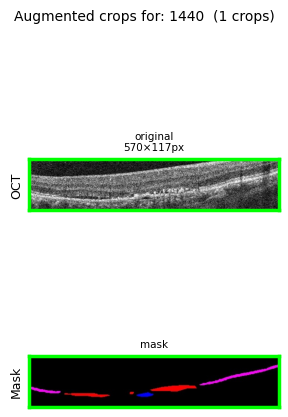

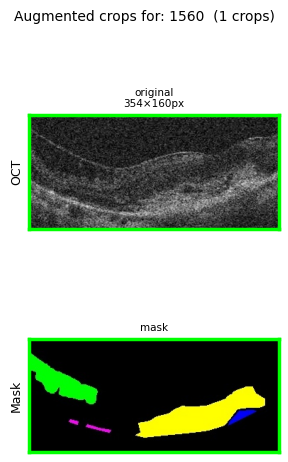

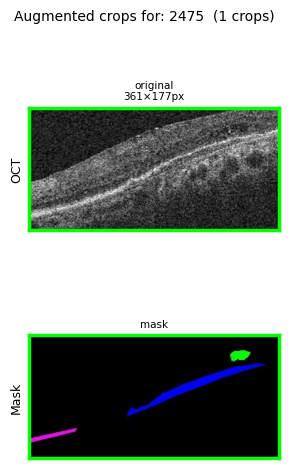

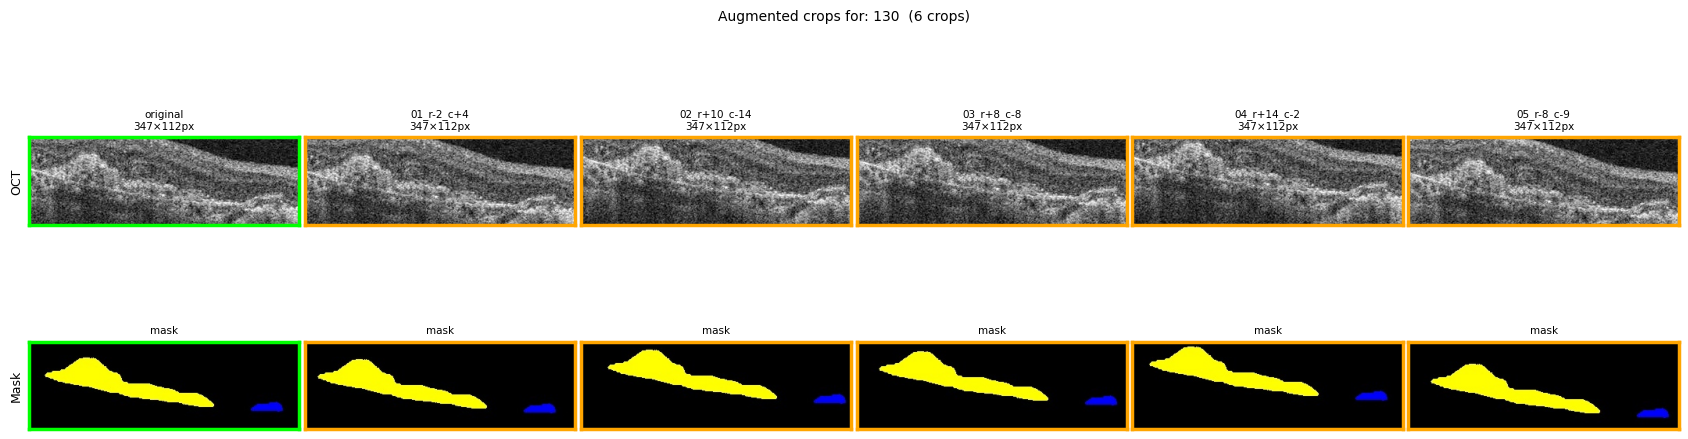

QC complete.

Augmented dataset ready in:
  OCT  : /content/drive/MyDrive/FYP/data/augmented/crop_oct
  Mask : /content/drive/MyDrive/FYP/data/augmented/crop_mask

Next step: use these folders as CROP_OCT_DIR / CROP_MASK_DIR
in finetune_unet_roi_fixed.ipynb for training.

  Colab tip: output is saved to Google Drive.
  It persists after this session ends.
  In your fine-tune notebook set:
    CROP_OCT_DIR  = "/content/drive/MyDrive/FYP/data/augmented/crop_oct"
    CROP_MASK_DIR = "/content/drive/MyDrive/FYP/data/augmented/crop_mask"


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 5 — QC: Random sample of saved augmented pairs
# Shows 4 random input images, each with their translated crops
# ══════════════════════════════════════════════════════════════════════════

out_oct_dir  = Path(OUT_OCT_DIR)
out_mask_dir = Path(OUT_MASK_DIR)

# Group output files by original stem
from collections import defaultdict
stem_groups = defaultdict(list)
for f in sorted(out_oct_dir.glob('*.png')):
    # Stem format: originalname_t01_r+12_c-8  →  original stem is before _t
    orig_stem = f.stem.split('_t')[0]
    stem_groups[orig_stem].append(f)

sample_stems = random.sample(list(stem_groups.keys()),
                              min(4, len(stem_groups)))

for orig_stem in sample_stems:
    files  = sorted(stem_groups[orig_stem])   # t00, t01, t02 ...
    n_show = len(files)

    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.8, 5.5))
    if axes.ndim == 1:
        axes = axes.reshape(2, -1)
    fig.suptitle(f'Augmented crops for: {orig_stem}  ({n_show} crops)',
                 fontsize=10)

    for col, fpath in enumerate(files):
        oct_c  = cv2.cvtColor(cv2.imread(str(fpath)), cv2.COLOR_BGR2RGB)
        mask_c = cv2.cvtColor(
            cv2.imread(str(out_mask_dir / fpath.name), cv2.IMREAD_COLOR),
            cv2.COLOR_BGR2RGB
        )
        h, w = oct_c.shape[:2]

        # Decode shift from filename
        parts = fpath.stem.split('_t')
        shift_label = 'original' if 't00' in fpath.stem else parts[-1]
        border_col = 'lime' if 't00' in fpath.stem else 'orange'

        axes[0, col].imshow(oct_c,  cmap='gray')
        axes[1, col].imshow(mask_c)
        axes[0, col].set_title(f'{shift_label}\n{w}×{h}px', fontsize=7.5)
        axes[1, col].set_title('mask', fontsize=7.5)

        for row in range(2):
            for spine in axes[row, col].spines.values():
                spine.set_edgecolor(border_col)
                spine.set_linewidth(2.5)
                spine.set_visible(True)
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])

    axes[0, 0].set_ylabel('OCT',  fontsize=9)
    axes[1, 0].set_ylabel('Mask', fontsize=9)
    plt.tight_layout(pad=0.4)
    plt.show()

print('QC complete.')
print(f'\nAugmented dataset ready in:')
print(f'  OCT  : {OUT_OCT_DIR}')
print(f'  Mask : {OUT_MASK_DIR}')
print()
print('Next step: use these folders as CROP_OCT_DIR / CROP_MASK_DIR')
print('in finetune_unet_roi_fixed.ipynb for training.')

# ── Colab session tip ─────────────────────────────────────────────────────
print('\n' + '='*60)
print('  Colab tip: output is saved to Google Drive.')
print('  It persists after this session ends.')
print('  In your fine-tune notebook set:')
print(f'    CROP_OCT_DIR  = "{OUT_OCT_DIR}"')
print(f'    CROP_MASK_DIR = "{OUT_MASK_DIR}"')
print('='*60)
